In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 8** - Maximising an 8D Black-Box Function

- Optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output but the internal mechanics are unknown. 
    - Because the function is high-dimensional and likely complex, global optimisation is hard, identifying strong local maxima is the practical strategy.

- For example, imagine tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (encoded), optimiser type (encoded) and initial weight range.

**Input** - 8D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise  
**All-time best:** 9.951 at [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476] (Week 3)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 8
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy')

# New data for Week 10 (Function 8)
X_w9_new_point = np.array([0.263413, 0.077268, 0.022492, 0.179458, 0.852835, 0.318308, 0.139938, 0.482812], dtype=np.float64)
Y_w9_new_point = np.array([9.8627648131831], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w9_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w9_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 8: ", X_unique)
print("Updated Outputs (Y) - Function 8: ", Y_updated)

Updated Inputs (X) - Function 8:  [[0.007838   0.337307   0.164679   0.407388   0.632409   0.551169
  0.306982   0.5023    ]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.014565   0.233424   0.15641    0.215734   0.993571   0.163832
  0.082661   0.95629   ]
 [0.02894663 0.02827906 0.48137155 0.6131746  0.67266045 0.02211341
  0.6014833  0.52488505]
 [0.029788   0.370437   0.009211   0.56322    0.914458   0.813905
  0.149129   0.554138  ]
 [0.0417     0.167136   0.185989   0.004377   0.961301   0.357272
  0.961301   0.357272  ]
 [0.04432925 0.01358149 0.25819824 0.57764416 0.05127992 0.15856307
  0.59103012 0.07795293]
 [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
  0.48830701 0.89308498]
 [0.097603   0.135405   0.156089   0.022873   0.887585   0.187209
  0.032006   0.53162   ]
 [0.110613   0.166799   0.129222   0.228937   0.996353   0.475272
  0.30197    0.476277  ]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.

## **Output Analysis**

- **w8 Output:** 9.800
- **W9 Output:** 9.863 ✅ Improvement

- **Comparison:** A genuine improvement and 9.863 is the second-highest result in the project history, behind only the w3 all-time best of 9.951. 
    - This continues the positive trend (9.800 → 9.863). 
    
    - The w9 query had $x_5 = 0.853$, which is below the optimal $x_5 \approx 0.996$ seen in the top result, yet still produced a strong score. 
        - This suggests that in w9, the other seven dimensions were well-configured enough to partially compensate for the sub-optimal $x_5$.

- **Real-World Implication:** In an 8D stochastic system achieving 9.863 out of ~10 across different parameter combinations confirms we are on a high-performance plateau. 
    - The stochastic nature of the function means a single reading cannot be definitively trusted
        - However, three consecutive results above 9.8 (w7: 9.823, w8: 9.800, w9: 9.863) provide statistical confidence that this region of the 8D space genuinely performs well. 
        
    - The remaining gap to 9.951 likely requires $x_5$ to be closer to 0.996 — the single most consistent predictor of the all-time best.

- **Model Clues:** Three weeks of results above 9.8 confirm we are on the right performance plateau. 
    - The difference between the w9 result and the w3 all-time best is primarily $x_5$ (0.853 vs 0.996). 
    - w10 must target $x_5 \approx 0.990$–$0.999$ while keeping the other dimensions close to the W3 profile.

## **Bayesian Optimisation** - Gaussian Process Regressor

- **Model:** Gaussian Process Regressor with Matern (nu=2.5) + WhiteKernel and Yeo-Johnson transformation.

- **Changes for W10 and Reasoning:**
    - I am increasing n_restarts_optimizer to 25 to ensure the GP finds the best internal kernel fit now that we have a clearer picture of the high-performance region. 
        - With 9+ weeks of data and a confirmed plateau above 9.8, the marginal likelihood landscape is complex enough to warrant more thorough optimisation restarts.
    - The Yeo-Johnson transformation is retained
    - I am maintaining the w3 best as the focused grid centre since it remains the all-time best and $x_5=0.996$ is the strongest predictor.

- **Theoretical Impact:** With 9 weeks of data, the GP's ARD length scales for this function should now meaningfully differentiate $x_5$ from the other seven dimensions. 
    - The three consecutive strong results have narrowed the GP's uncertainty in the high-$x_5$ region, meaning the UCB surface will be more precisely targeted around the confirmed high-performance zone.

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

# Matern 2.5 + WhiteKernel — stable for the stochastic 8D landscape
# Higher noise level (1e-5) prevents overfitting to stochastic fluctuations
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
model.fit(X_unique, Y_transformed)

Original Y: [9.83756547 8.45948162 9.80005381 8.83074505 9.61655465 8.76386781
 9.01307515 9.598482   9.82298699 9.95104443 7.85454099 9.87247349
 8.97655402 9.14163949 6.45194313 7.00522736 9.34427428 9.70409915
 9.86276481 8.81755844 7.13162397 8.60611679 7.92375877 8.2780624
 7.69236805 8.47293632 9.18300525 8.28400781 8.04221254 8.42175924
 7.29987205 7.3987211  7.43374407 6.76796253 7.95787474 7.3790829
 7.31089382 8.54174792 6.79198578 7.43659353 7.46087219 7.97768459
 8.15998319 5.84106731 7.32743458 6.88784639 6.40258841 5.59219339
 7.11345716]
Transformed Y: [ 1.51604406  0.24245788  1.48047336  0.57872486  1.30718153  0.51777088
  0.74574654  1.29017848  1.50221406  1.62395041 -0.29419691  1.54919003
  0.71219366  0.86425029 -1.48179096 -1.02310862  1.05224758  1.38970834
  1.53996714  0.56669303 -0.91650202  0.37465258 -0.2335136   0.08003463
 -0.4356318   0.25455369  0.90250715  0.08533757 -0.12922871  0.208582
 -0.77356773 -0.68904826 -0.65900669 -1.22140999 -0.20353476 -0

/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Strategy:** Upper Confidence Bound (UCB) with $\beta = 2.0$

- **Reasoning:** In an 8D stochastic function, a small amount of exploration pressure is always warranted, the noise means a single reading cannot fully confirm we are at the true peak. 
    - $\beta = 2.0$ maintains just enough exploration to avoid getting locked onto a noise-inflated result while still keeping the search focused on the high-performance plateau.

- **Key Changes:**
    - Focused grid centred on w3 all-time best [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476] with std=0.02.
    - 75/25 focused-to-uniform split, meaning the larger uniform component is retained to account for the stochastic nature of this function.

- **Intended Impact:** Surpass the all-time best of 9.951 by precisely targeting $x_5 \approx 0.996$ while keeping the remaining seven dimensions close to the confirmed high-performance profile.

In [4]:
def upper_confidence_bound(X, model, beta=2.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

# W3 all-time best — x5=0.996 is the critical dimension
w3_best = np.array([0.110613, 0.166799, 0.129222, 0.228937, 0.996353, 0.475272, 0.301970, 0.476277])

# 75% Focused, 25% Uniform — larger uniform for stochastic coverage
x_focused = np.random.normal(loc=w3_best, scale=0.02, size=(7500, 8))
x_uniform = np.random.uniform(0, 1, size=(2500, 8))
x_grid = np.clip(np.vstack([x_focused, x_uniform]), 0, 1)

ucb_values = upper_confidence_bound(x_grid, model, beta=2.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f"W3 best coordinates: {w3_best}")
print(f"Next Query Point (F8): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}-{next_query[6]:.6f}-{next_query[7]:.6f}")

W3 best coordinates: [0.110613 0.166799 0.129222 0.228937 0.996353 0.475272 0.30197  0.476277]
Next Query Point (F8): 0.153344-0.374338-0.010438-0.235838-0.756491-0.450377-0.195188-0.615623


## **Visualisations**

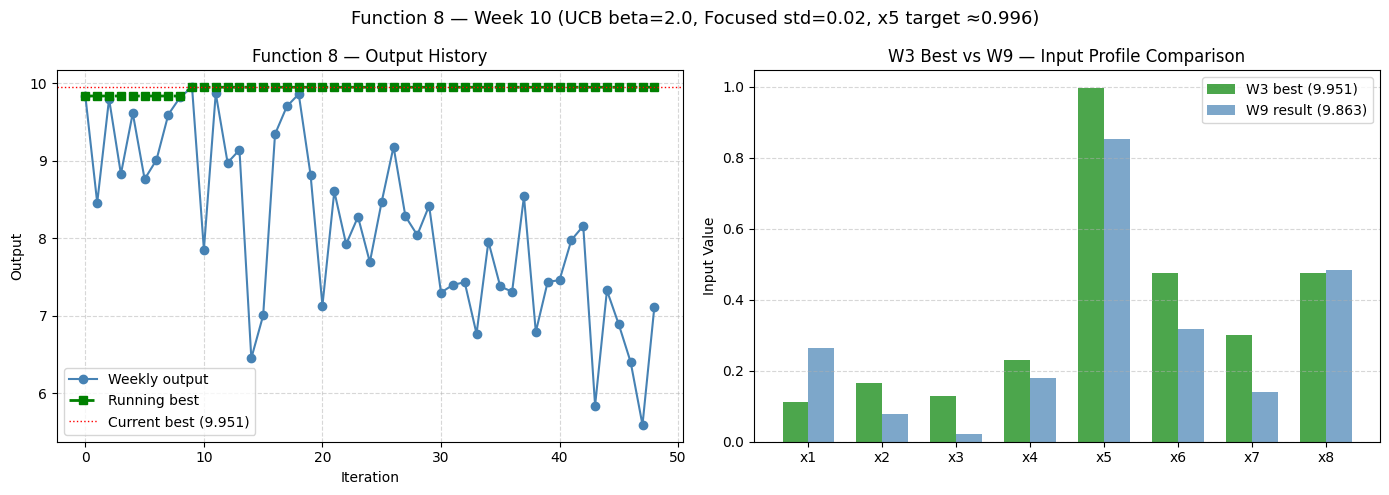

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(np.max(Y_updated), color='red', linestyle=':', linewidth=1,
                label=f'Current best ({np.max(Y_updated):.3f})')
axes[0].set_title('Function 8 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

dim_labels = [f'x{i+1}' for i in range(8)]
x_pos = np.arange(8)
width = 0.35
axes[1].bar(x_pos - width/2, w3_best, width, label='W3 best (9.951)', color='green', alpha=0.7)
axes[1].bar(x_pos + width/2, X_w9_new_point, width, label='W9 result (9.863)', color='steelblue', alpha=0.7)
axes[1].set_title('W3 Best vs W9 — Input Profile Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(dim_labels)
axes[1].set_ylabel('Input Value')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 8 — Week 10 (UCB beta=2.0, Focused std=0.02, x5 target ≈0.996)', fontsize=13)
plt.tight_layout()
plt.show()